Filtered runs: 4
Skip empty matrix: single: Stage-level Transition Matrix
Skip empty matrix: single: Failure-type Transition Matrix


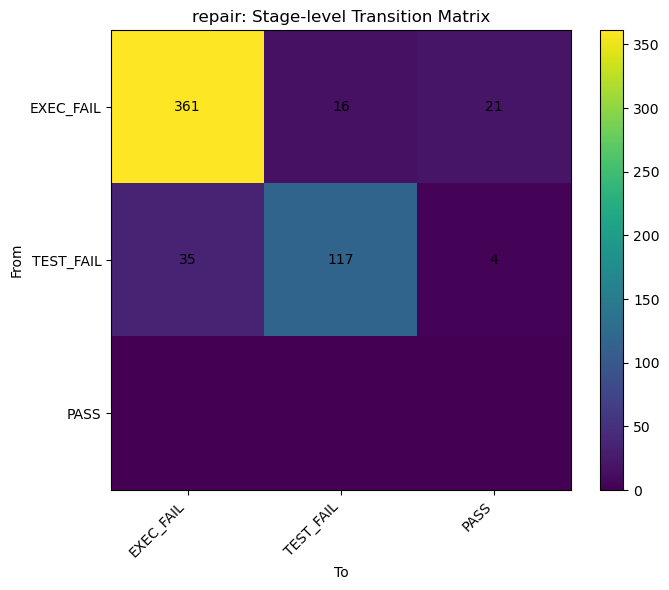

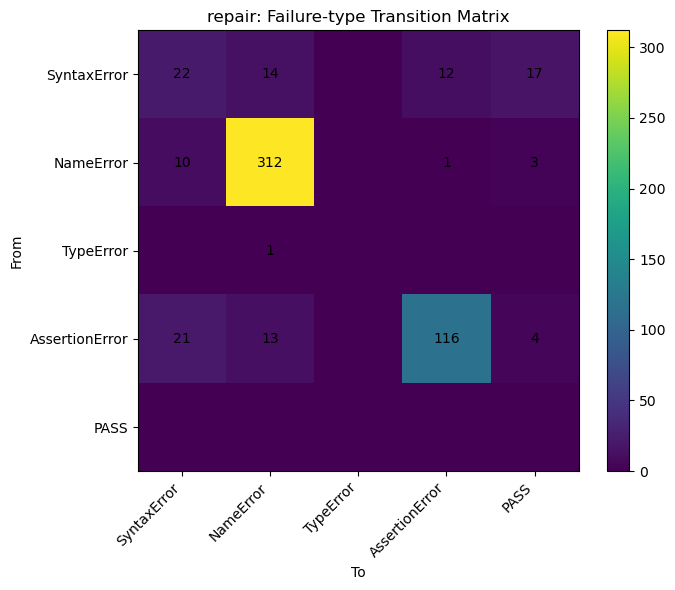

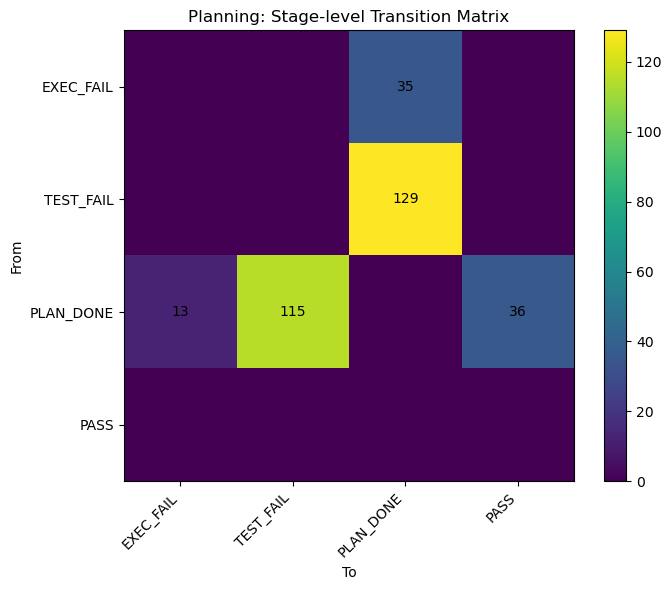

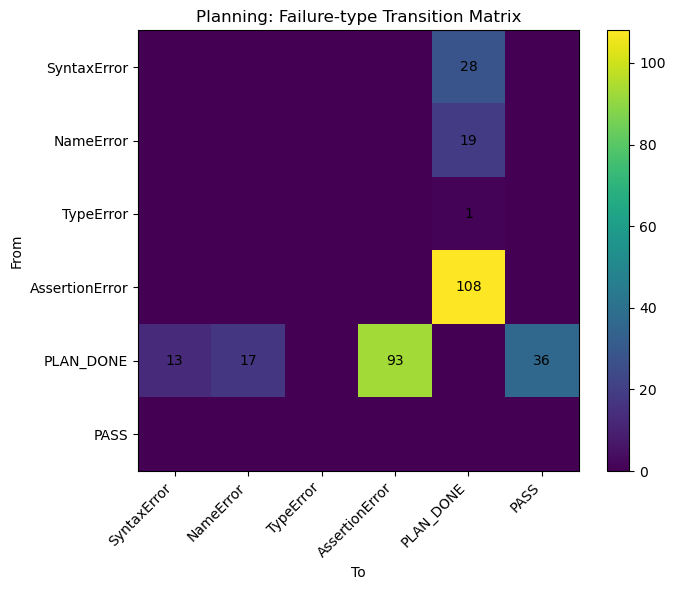

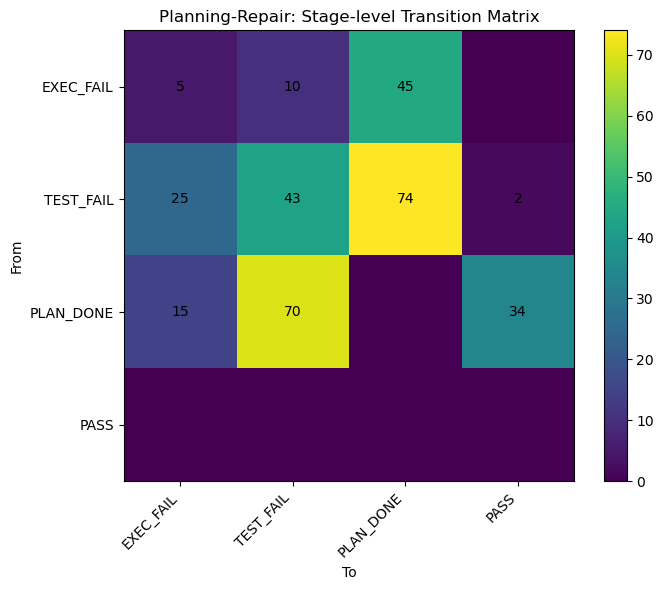

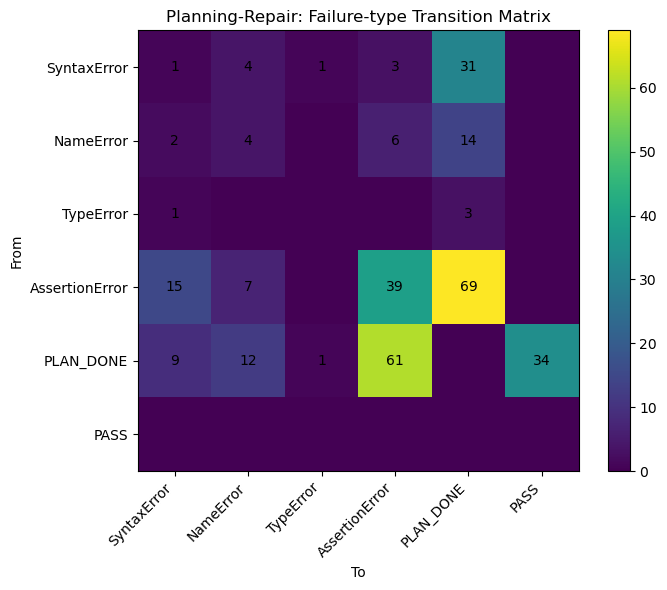

Saved transition matrices and heatmaps to: transition_heatmaps


In [1]:
import json
from pathlib import Path

import pandas as pd


RESULTS_ROOT = Path("../results")


# --------------------------------------------------
# run 자동 탐색
# --------------------------------------------------
def discover_runs(results_root: Path):
    runs = []
    

    for traj_path in results_root.rglob("trajectory_logs.jsonl"):
        parts = traj_path.parent.relative_to(results_root).parts

        if len(parts) < 3:
            continue

        model, dataset, strategy = parts[:3]
        
        

        runs.append({
            "model": model,
            "dataset": dataset,
            "strategy": strategy,
            "trajectory_path": traj_path,
        })

    return runs


# --------------------------------------------------
# trajectory_logs.jsonl 읽기
# --------------------------------------------------
def read_jsonl(path):
    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line:
                rows.append(json.loads(line))

    return rows


# --------------------------------------------------
# 전략 이름 pretty mapping
# --------------------------------------------------
STRATEGY_NAME_MAP = {
    "single_shot": "Single-shot",
    "repair_loop": "Repair",
    "code_then_plan": "Planning",
    "code_then_plan_repair": "Planning-Repair",
}


# --------------------------------------------------
# HumanEval + qwen25coder7b 필터
# --------------------------------------------------
runs = discover_runs(RESULTS_ROOT)

filtered_runs = [
    r for r in runs
    if r["dataset"] == "humaneval"
    and "qwen25coder7b" in r["model"] and not "proposed_v1" in r["strategy"] and not "proposed_v2" in r["strategy"]
]

print(f"Filtered runs: {len(filtered_runs)}")


import re
import matplotlib.pyplot as plt


OUTPUT_DIR = Path("./transition_heatmaps")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------
# transition state parsing
# --------------------------------------------------
def parse_stage_state(state: str) -> str:
    """
    stage-level state로 변환.
    예:
      EXEC_FAIL:SyntaxError -> EXEC_FAIL
      TEST_FAIL:AssertionError -> TEST_FAIL
      PASS -> PASS
      PLAN_DONE -> PLAN_DONE
    """
    if state == "PASS":
        return "PASS"
    if state == "PLAN_DONE":
        return "PLAN_DONE"
    if isinstance(state, str) and ":" in state:
        return state.split(":", 1)[0]
    return str(state)


def parse_failure_type_state(state: str) -> str:
    """
    failure-type-level state로 변환.
    예:
      EXEC_FAIL:SyntaxError -> SyntaxError
      TEST_FAIL:AssertionError -> AssertionError
      PASS -> PASS
      PLAN_DONE -> PLAN_DONE
    """
    if state == "PASS":
        return "PASS"
    if state == "PLAN_DONE":
        return "PLAN_DONE"
    if isinstance(state, str) and ":" in state:
        return state.split(":", 1)[1]
    return str(state)


# --------------------------------------------------
# transition pair 추출
# --------------------------------------------------
def extract_transition_pairs(rows, parser):
    """
    trajectory_logs.jsonl rows에서 transition_path를 읽고
    pairwise transition을 추출.
    """
    pairs = []

    for r in rows:
        path = r.get("transition_path", [])

        if not isinstance(path, list) or len(path) < 2:
            continue

        parsed_path = [parser(s) for s in path]

        for src, dst in zip(parsed_path[:-1], parsed_path[1:]):
            pairs.append((src, dst))

    return pairs


# --------------------------------------------------
# transition matrix 생성
# --------------------------------------------------
def build_transition_matrix(pairs, state_order=None):
    if not pairs:
        return pd.DataFrame()

    pair_df = pd.DataFrame(pairs, columns=["from", "to"])

    matrix = pd.crosstab(
        pair_df["from"],
        pair_df["to"]
    )

    if state_order is None:
        states = sorted(set(pair_df["from"]).union(set(pair_df["to"])))
    else:
        states = [
            s for s in state_order
            if s in set(pair_df["from"]).union(set(pair_df["to"]))
        ]

    matrix = matrix.reindex(
        index=states,
        columns=states,
        fill_value=0
    )

    return matrix


# --------------------------------------------------
# heatmap 그리기
# --------------------------------------------------
def plot_heatmap(matrix, title, output_path):
    if matrix.empty:
        print(f"Skip empty matrix: {title}")
        return

    fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(matrix.values)

    ax.set_title(title)
    ax.set_xlabel("To")
    ax.set_ylabel("From")

    ax.set_xticks(range(len(matrix.columns)))
    ax.set_yticks(range(len(matrix.index)))

    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(matrix.index)

    # cell count annotation
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.iloc[i, j]
            if value > 0:
                ax.text(
                    j,
                    i,
                    str(value),
                    ha="center",
                    va="center"
                )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


# --------------------------------------------------
# stage-level / failure-type-level state order
# --------------------------------------------------
STAGE_ORDER = [
    "EXEC_FAIL",
    "TEST_FAIL",
    "PLAN_DONE",
    "PASS",
]

FAILURE_TYPE_ORDER = [
    "SyntaxError",
    "NameError",
    "TypeError",
    "AssertionError",
    "PLAN_DONE",
    "PASS",
]


# --------------------------------------------------
# 전략별 transition matrix + heatmap 생성
# --------------------------------------------------
all_stage_matrices = {}
all_type_matrices = {}

for run in filtered_runs:
    rows = read_jsonl(run["trajectory_path"])

    strategy_key = run["strategy"]
    pretty_name = STRATEGY_NAME_MAP.get(strategy_key, strategy_key)

    # stage-level
    stage_pairs = extract_transition_pairs(
        rows,
        parser=parse_stage_state
    )

    stage_matrix = build_transition_matrix(
        stage_pairs,
        state_order=STAGE_ORDER
    )

    all_stage_matrices[pretty_name] = stage_matrix

    stage_csv_path = OUTPUT_DIR / f"{pretty_name}_stage_transition_matrix.csv"
    stage_png_path = OUTPUT_DIR / f"{pretty_name}_stage_transition_heatmap.png"

    stage_matrix.to_csv(stage_csv_path)

    plot_heatmap(
        stage_matrix,
        title=f"{pretty_name}: Stage-level Transition Matrix",
        output_path=stage_png_path
    )

    # failure-type-level
    type_pairs = extract_transition_pairs(
        rows,
        parser=parse_failure_type_state
    )

    type_matrix = build_transition_matrix(
        type_pairs,
        state_order=FAILURE_TYPE_ORDER
    )

    all_type_matrices[pretty_name] = type_matrix

    type_csv_path = OUTPUT_DIR / f"{pretty_name}_failure_type_transition_matrix.csv"
    type_png_path = OUTPUT_DIR / f"{pretty_name}_failure_type_transition_heatmap.png"

    type_matrix.to_csv(type_csv_path)

    plot_heatmap(
        type_matrix,
        title=f"{pretty_name}: Failure-type Transition Matrix",
        output_path=type_png_path
    )


print(f"Saved transition matrices and heatmaps to: {OUTPUT_DIR}")

In [2]:
# Repair만 보기
repair_run = [r for r in filtered_runs if r["strategy"] == "repair"]
rows = read_jsonl(repair_run[0]["trajectory_path"])

# failure-type 단위 matrix
type_pairs = extract_transition_pairs(rows, parser=parse_failure_type_state)

type_matrix = build_transition_matrix(
    type_pairs,
    state_order=[
        "AssertionError",
        "SyntaxError",
        "NameError",
        "TypeError",
        "PASS",
        "PLAN_DONE",
    ],
)

# 보기 좋은 순서로 column 재정렬
type_matrix = type_matrix.reindex(
    index=["AssertionError", "SyntaxError", "NameError", "TypeError"],
    columns=["PASS", "AssertionError", "SyntaxError", "NameError", "TypeError"],
    fill_value=0,
)

print(type_matrix)
type_matrix.to_csv("./archive/repair_failure_type_transition_matrix.csv")
print(type_matrix.to_latex())

to              PASS  AssertionError  SyntaxError  NameError  TypeError
from                                                                   
AssertionError     4             116           21         13          0
SyntaxError       17              12           22         14          0
NameError          3               1           10        312          0
TypeError          0               0            0          1          0
\begin{tabular}{lrrrrr}
\toprule
to & PASS & AssertionError & SyntaxError & NameError & TypeError \\
from &  &  &  &  &  \\
\midrule
AssertionError & 4 & 116 & 21 & 13 & 0 \\
SyntaxError & 17 & 12 & 22 & 14 & 0 \\
NameError & 3 & 1 & 10 & 312 & 0 \\
TypeError & 0 & 0 & 0 & 1 & 0 \\
\bottomrule
\end{tabular}



In [3]:
stage_pairs = extract_transition_pairs(rows, parser=parse_stage_state)

stage_matrix = build_transition_matrix(
    stage_pairs,
    state_order=["EXEC_FAIL", "TEST_FAIL", "PASS", "PLAN_DONE"],
)

stage_matrix = stage_matrix.reindex(
    index=["EXEC_FAIL", "TEST_FAIL"],
    columns=["PASS", "EXEC_FAIL", "TEST_FAIL"],
    fill_value=0,
)

print(stage_matrix)
stage_matrix.to_csv("repair_stage_transition_matrix.csv")
print(stage_matrix.to_latex())

to         PASS  EXEC_FAIL  TEST_FAIL
from                                 
EXEC_FAIL    21        361         16
TEST_FAIL     4         35        117
\begin{tabular}{lrrr}
\toprule
to & PASS & EXEC_FAIL & TEST_FAIL \\
from &  &  &  \\
\midrule
EXEC_FAIL & 21 & 361 & 16 \\
TEST_FAIL & 4 & 35 & 117 \\
\bottomrule
\end{tabular}



In [4]:
for run in filtered_runs:
    rows = read_jsonl(run["trajectory_path"])
    strategy = STRATEGY_NAME_MAP.get(run["strategy"], run["strategy"])

    type_pairs = extract_transition_pairs(rows, parser=parse_failure_type_state)
    type_matrix = build_transition_matrix(type_pairs)

    out = type_matrix.reindex(
        index=["AssertionError", "SyntaxError", "NameError", "TypeError"],
        columns=["PASS", "AssertionError", "SyntaxError", "NameError", "TypeError", "PLAN_DONE"],
        fill_value=0,
    )

    print(f"\n{strategy} failure-type transition matrix")
    print(out)

    out.to_csv(f"./archive/{strategy}_failure_type_transition_matrix.csv")


single failure-type transition matrix
                PASS  AssertionError  SyntaxError  NameError  TypeError  \
AssertionError     0               0            0          0          0   
SyntaxError        0               0            0          0          0   
NameError          0               0            0          0          0   
TypeError          0               0            0          0          0   

                PLAN_DONE  
AssertionError          0  
SyntaxError             0  
NameError               0  
TypeError               0  

repair failure-type transition matrix
to              PASS  AssertionError  SyntaxError  NameError  TypeError  \
from                                                                      
AssertionError     4             116           21         13          0   
SyntaxError       17              12           22         14          0   
NameError          3               1           10        312          0   
TypeError          0           